# Student's t, Mann-Whitney, Wilcoxon, and Wald as one modeling family

This notebook is based on Jonas Kristoffer Lindelov's essay, [*Common statistical tests are linear models (or: how to teach stats)*](https://lindeloev.github.io/tests-as-linear/).

The central idea from the reading is:

- many familiar tests can be understood as coefficient tests in linear models,
- many so-called non-parametric tests can be understood through the same models after replacing values by ranks or signed ranks,
- and Wald tests provide a general coefficient-testing framework that is closely connected to t-tests in simple ordinary least squares settings.

We will use two worked examples:

1. two independent groups: Student's independent-samples t-test and Mann-Whitney U,
2. paired measurements: paired t-test and Wilcoxon signed-rank,

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(42)


def signed_rank(x):
    """Return signed ranks after dropping zeros, matching Wilcoxon's usual setup."""
    x = np.asarray(x)
    nonzero = x != 0
    x_nz = x[nonzero]
    ranks = stats.rankdata(np.abs(x_nz), method="average")
    return np.sign(x_nz) * ranks


def _get_by_position(values, index):
    return values.iloc[index] if hasattr(values, "iloc") else values[index]


def summarize_ols(result, param_index=1):
    beta = _get_by_position(result.params, param_index)
    se = _get_by_position(result.bse, param_index)
    t_value = _get_by_position(result.tvalues, param_index)
    p_value = _get_by_position(result.pvalues, param_index)
    return pd.Series({"estimate": beta, "se": se, "t": t_value, "p": p_value})


def intercept_summary(result):
    beta = _get_by_position(result.params, 0)
    se = _get_by_position(result.bse, 0)
    t_value = _get_by_position(result.tvalues, 0)
    p_value = _get_by_position(result.pvalues, 0)
    return pd.Series({"estimate": beta, "se": se, "t": t_value, "p": p_value})

## Example 1: independent groups

The two model views are:

- **Student's t-test**: `y = beta_0 + beta_1 * group + error`
- **Mann-Whitney U approximation**: `rank(y) = beta_0 + beta_1 * group + error`

Here `beta_1` is the difference between group means on the chosen scale:
- in the first model, the difference in mean raw values,
- in the second model, the difference in mean ranks.

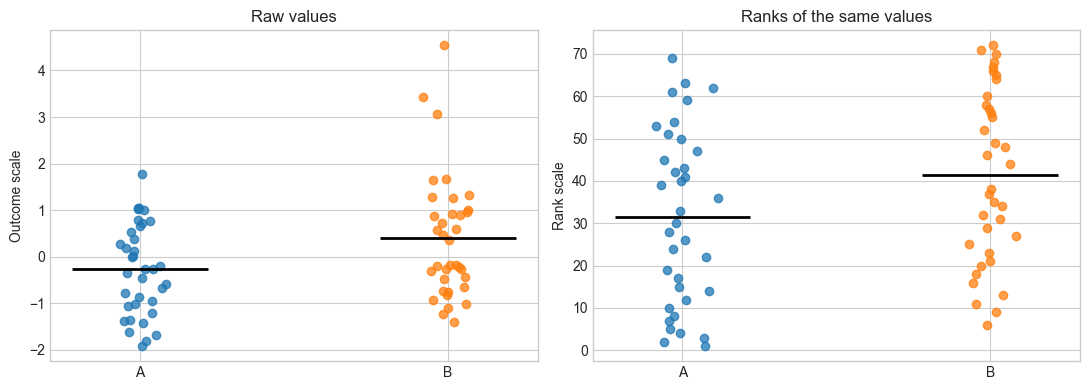

In [24]:
n_a = 36
n_b = 36

# Two groups with skew and a shift in location.
group_a = rng.gamma(shape=2.2, scale=1.0, size=n_a) - 2.3
group_b = rng.gamma(shape=2.2, scale=1.0, size=n_b) - 1.6

y = np.concatenate([group_a, group_b])
group = np.concatenate([np.zeros(n_a), np.ones(n_b)])
X = sm.add_constant(group)

df_ind = pd.DataFrame({
    "value": y,
    "group": np.where(group == 0, "A", "B"),
    "group01": group,
    "rank_value": stats.rankdata(y, method="average"),
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in [
    (axes[0], "value", "Raw values"),
    (axes[1], "rank_value", "Ranks of the same values"),
]:
    for i, label in enumerate(["A", "B"]):
        vals = df_ind.loc[df_ind["group"] == label, col].to_numpy()
        xj = rng.normal(i, 0.04, size=len(vals))
        ax.scatter(xj, vals, alpha=0.75, label=label)
        ax.hlines(vals.mean(), i - 0.22, i + 0.22, colors="black", linewidth=2)
    ax.set_xticks([0, 1], ["A", "B"])
    ax.set_title(title)
axes[0].set_ylabel("Outcome scale")
axes[1].set_ylabel("Rank scale")
plt.tight_layout()

In [25]:
# Classical independent-samples Student's t-test.
student_ind = stats.ttest_ind(group_a, group_b, equal_var=True)

# Same model expressed as Ordinary Least Squares (OLS) with a 0/1 dummy variable.
ols_ind = sm.OLS(y, X).fit()
ols_ind_summary = summarize_ols(ols_ind)

# Mann-Whitney U and its linear-model approximation on ranks.
mw = stats.mannwhitneyu(group_a, group_b, alternative="two-sided", method="asymptotic")
ols_rank = sm.OLS(df_ind["rank_value"], X).fit()
ols_rank_summary = summarize_ols(ols_rank)

comparison_ind = pd.DataFrame([
    {
        "test": "Student independent t-test",
        "statistic": student_ind.statistic,
        "p_value": student_ind.pvalue,
    },
    {
        "test": "Ordinary Least Squares slope test on raw values",
        "statistic": ols_ind_summary["t"],
        "p_value": ols_ind_summary["p"],
    },
    {
        "test": "Mann-Whitney U (asymptotic)",
        "statistic": mw.statistic,
        "p_value": mw.pvalue,
    },
    {
        "test": "Ordinary Least Squares slope test on ranks",
        "statistic": ols_rank_summary["t"],
        "p_value": ols_rank_summary["p"],
    },
])

comparison_ind.round(4)

,test,statistic,p_value
0,Student independent t-test,-2.4248,0.0179
1,Ordinary Least Squares slope test on raw values,2.4248,0.0179
2,Mann-Whitney U (asymptotic),469.0000,0.0444
3,Ordinary Least Squares slope test on ranks,2.0616,0.0430


## Example 2: paired measurements

Now switch to paired data, where each subject has a before and after value.

The paired t-test is just a one-sample t-test on the pairwise differences:

`d = after - before = beta_0 + error`

Wilcoxon signed-rank uses the same intercept-only structure, but on signed ranks:

`signed_rank(d) = beta_0 + error`

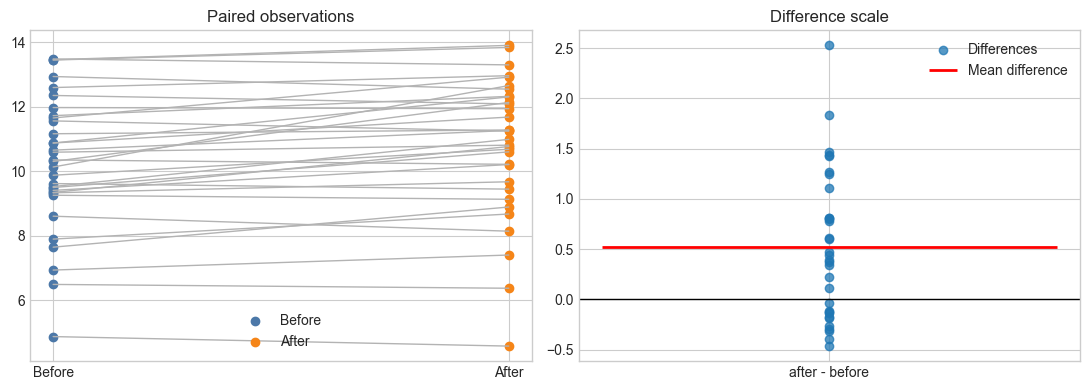

In [26]:
n_pairs = 32
before = rng.normal(loc=10.0, scale=2.0, size=n_pairs)

# Improvement with skewed noise so the rank-based view is interesting.
diff = rng.gamma(shape=2.0, scale=0.45, size=n_pairs) - 0.55
after = before + diff

paired_diff = after - before
paired_signed_ranks = signed_rank(paired_diff)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i in range(n_pairs):
    axes[0].plot([0, 1], [before[i], after[i]], color="0.7", linewidth=1)
axes[0].scatter(np.zeros(n_pairs), before, color="#4C78A8", label="Before")
axes[0].scatter(np.ones(n_pairs), after, color="#F58518", label="After")
axes[0].set_xticks([0, 1], ["Before", "After"])
axes[0].set_title("Paired observations")
axes[0].legend()

axes[1].axhline(0, color="black", linewidth=1)
axes[1].scatter(np.zeros_like(paired_diff), paired_diff, alpha=0.75, label="Differences")
axes[1].hlines(paired_diff.mean(), -0.2, 0.2, colors="red", linewidth=2, label="Mean difference")
axes[1].set_xticks([0], ["after - before"])
axes[1].set_title("Difference scale")
axes[1].legend()
plt.tight_layout()

In [27]:
# Paired Student's t-test.
paired_t = stats.ttest_rel(after, before)

# Same test as an intercept-only OLS model on the differences.
ols_paired = sm.OLS(paired_diff, np.ones((len(paired_diff), 1))).fit()
ols_paired_summary = intercept_summary(ols_paired)

# Wilcoxon signed-rank and its signed-rank linear-model approximation.
wilcox = stats.wilcoxon(paired_diff, alternative="two-sided", correction=False, method="approx")
ols_signed_rank = sm.OLS(paired_signed_ranks, np.ones((len(paired_signed_ranks), 1))).fit()
ols_signed_rank_summary = intercept_summary(ols_signed_rank)

comparison_paired = pd.DataFrame([
    {
        "test": "Paired Student t-test",
        "statistic": paired_t.statistic,
        "p_value": paired_t.pvalue,
    },
    {
        "test": "Ordinary Least Squares intercept test on differences",
        "statistic": ols_paired_summary["t"],
        "p_value": ols_paired_summary["p"],
    },
    {
        "test": "Wilcoxon signed-rank (approx)",
        "statistic": wilcox.statistic,
        "p_value": wilcox.pvalue,
    },
    {
        "test": "Ordinary Least Squares intercept test on signed ranks",
        "statistic": ols_signed_rank_summary["t"],
        "p_value": ols_signed_rank_summary["p"],
    },
])

comparison_paired.round(4)

,test,statistic,p_value
0,Paired Student t-test,3.9854,0.0004
1,Ordinary Least Squares intercept test on diffe...,3.9854,0.0004
2,Wilcoxon signed-rank (approx),88.0000,0.0010
3,Ordinary Least Squares intercept test on signe...,3.9825,0.0004


### Interpretation

- The **paired t-test** and the **intercept-only Ordinary Least Squares test on differences** are the same test.
- The **Wilcoxon signed-rank** test becomes much easier to understand once we replace each nonzero difference by its signed rank and use the same intercept-only idea.
- Many non-parametric tests are best understood as **rank-space versions or approximations of familiar parametric models**, rather than as totally separate tools.

## The Wald connection

A Wald test asks whether a coefficient is far enough from its null value compared with its uncertainty.

For one parameter, the generic form is:

$$W = \left(\frac{\hat{\beta} - \beta_0}{SE(\hat{\beta})}\right)^2$$

Inside ordinary least squares:

- `t = (estimate - null) / SE`,
- so for a one-parameter coefficient test, `t^2` gives the corresponding Wald statistic.

That means the Student test follows the same coefficient-testing logic that appears more generally in Wald tests.

In [28]:
# Wald test for the group coefficient in the same independent-groups OLS model.
beta_hat = ols_ind.params[1]
se_hat = ols_ind.bse[1]
t_stat = ols_ind.tvalues[1]
wald_manual = (beta_hat / se_hat) ** 2

# Test the restriction beta_group = 0 with statsmodels.
R = np.array([[0, 1]])
wald_f = ols_ind.wald_test(R, use_f=True, scalar=True)
wald_chi2 = ols_ind.wald_test(R, use_f=False, scalar=True)

wald_df = pd.DataFrame([
    {"quantity": "Ordinary Least Squares t statistic for beta_group", "value": t_stat},
    {"quantity": "t^2", "value": t_stat ** 2},
    {"quantity": "Manual Wald chi-square", "value": float(wald_manual)},
    {"quantity": "statsmodels Wald F", "value": float(wald_f.statistic)},
    {"quantity": "statsmodels Wald chi-square", "value": float(wald_chi2.statistic)},
])

wald_df.round(6)

,quantity,value
0,Ordinary Least Squares t statistic for beta_group,2.424762
1,t^2,5.879472
2,Manual Wald chi-square,5.879472
3,statsmodels Wald F,5.879472
4,statsmodels Wald chi-square,5.879472


So the relationship is:

- **Student's t-test**: a coefficient test in a Gaussian linear model,
- **Mann-Whitney**: can be understood as the same kind of coefficient test after ranking the outcome,
- **Wilcoxon signed-rank**: can be understood as the same intercept test after taking signed ranks of paired differences,
- **Wald test**: the broader coefficient-testing idea, asking whether an estimate is many standard errors away from its null value.